# GOOG Quantitative Financial Analysis

This notebook focuses on loading historical stock price data, computing technical indicators, and visualizing market behavior using financial analysis techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("../data/raw/yfinance_data//Data/GOOG.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [5]:
df.shape

(3774, 6)

## Data Preparation

This section prepares the stock price dataset for quantitative analysis by checking data types, handling missing values, and formatting date information.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.set_index('Date', inplace=True)

In [9]:
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

### SMA

In [10]:
df['SMA_20'] = SMAIndicator(
    close=df['Close'],
    window=20
).sma_indicator()

### EMA

In [11]:
df['EMA_20'] = EMAIndicator(
    close=df['Close'],
    window=20
).ema_indicator()

### RSI

In [12]:
df['RSI'] = RSIIndicator(
    close=df['Close'],
    window=14
).rsi()

### MACD

In [13]:
macd = MACD(close=df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

## Visualization

### Price + Moving Averages

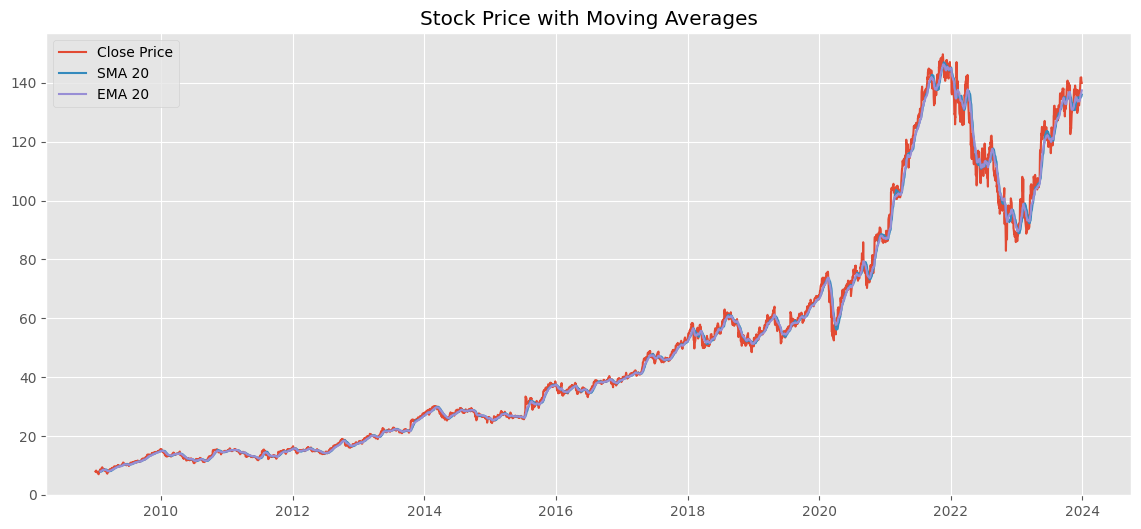

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.plot(df.index, df['EMA_20'], label='EMA 20')

plt.title('Stock Price with Moving Averages')

plt.legend()

plt.show()

### Moving Average Analysis

The stock demonstrates a strong long-term upward trend, particularly during the later years of the dataset. The 20-day SMA and EMA closely follow price movement, with the EMA reacting more quickly to short-term fluctuations. The sharp price increase and volatility observed near 2020 may reflect heightened market activity during major economic events.

### RSI Plot

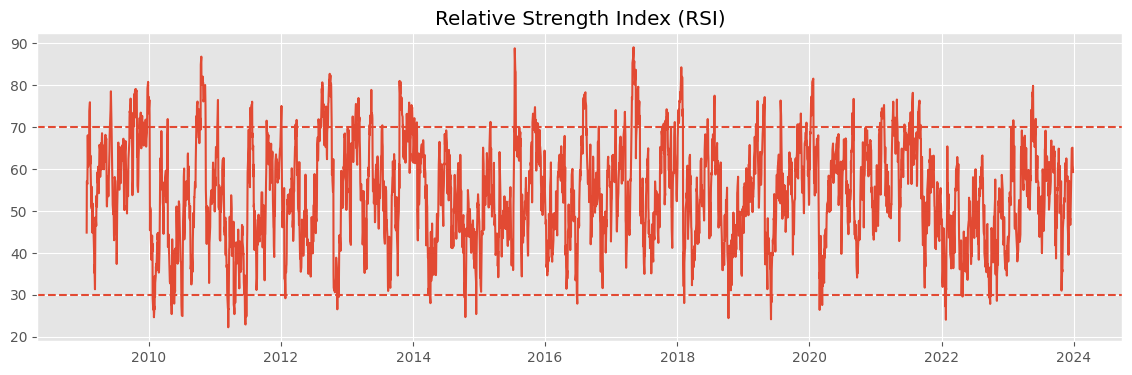

In [15]:
plt.figure(figsize=(14,4))

plt.plot(df.index, df['RSI'])

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('Relative Strength Index (RSI)')

plt.show()

### Relative Strength Index (RSI) Analysis

The RSI fluctuates consistently between overbought and oversold regions throughout the observed period. Several instances where RSI approaches or exceeds 70 suggest periods of strong buying momentum, while dips toward 30 indicate potential oversold conditions and possible market corrections.

### MACD Plot

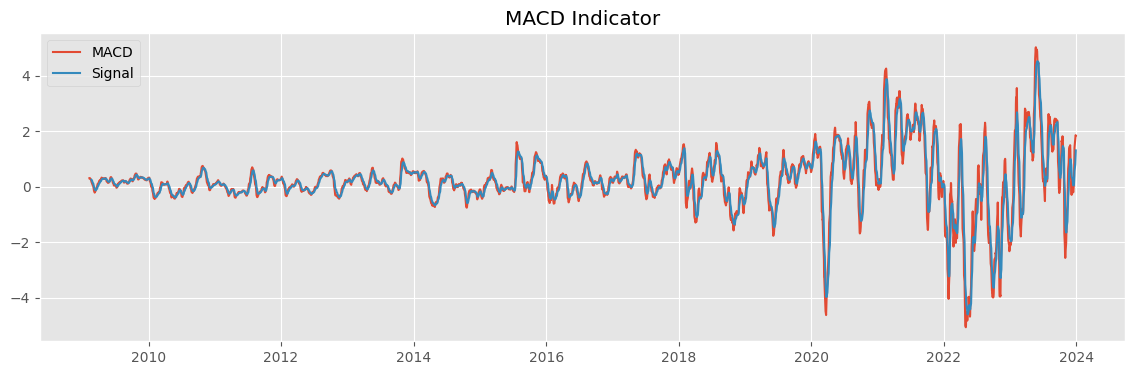

In [16]:
plt.figure(figsize=(14,4))

plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal')

plt.legend()

plt.title('MACD Indicator')

plt.show()

### MACD Analysis

The MACD indicator shows multiple momentum shifts and crossover behaviors over time. Increased volatility and larger oscillations near the end of the timeline suggest stronger momentum changes and heightened uncertainty during that market period.

## Additional Financial Metrics Using PyNance

Additional financial performance metrics were computed to complement the technical indicators and provide deeper insight into stock return behavior and volatility characteristics.

### Daily Returns

In [17]:
df['Daily_Return'] = df['Close'].pct_change()

df['Cumulative_Return'] = (
    1 + df['Daily_Return']
).cumprod()

volatility = df['Daily_Return'].std()

average_daily_return = df['Daily_Return'].mean()

In [18]:
print(f"Volatility: {volatility}")

print(f"Average Daily Return: {average_daily_return}")

Volatility: 0.017333544613474586
Average Daily Return: 0.0009101729662696578


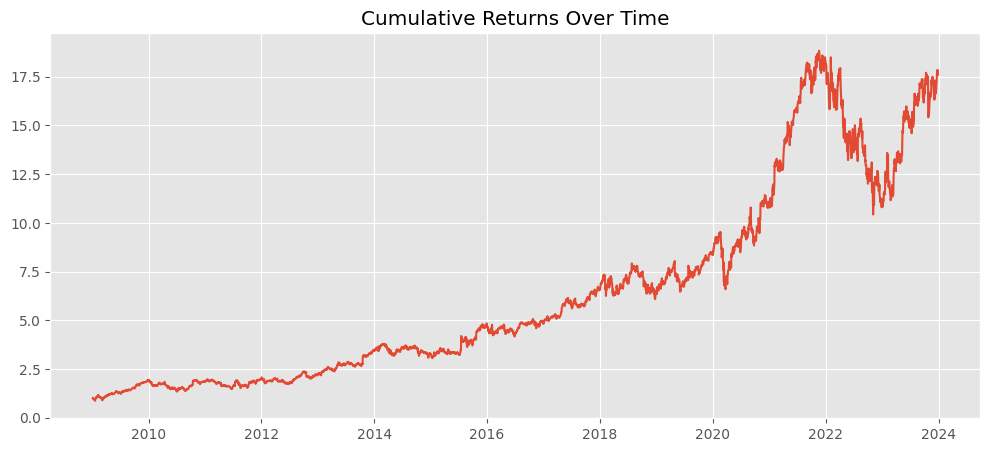

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Cumulative_Return'])

plt.title('Cumulative Returns Over Time')

plt.show()

### Insight

The cumulative return trend indicates substantial long-term growth in the stock price over the observed period, although periods of elevated volatility and short-term drawdowns are also visible.

Additional financial metrics inspired by PyNance functionality were computed to evaluate stock return behavior and volatility characteristics.

# Conclusion

The quantitative analysis successfully applied technical indicators to evaluate stock price behavior and market momentum. Moving averages highlighted overall trend direction, RSI identified periods of potential overbought and oversold activity, and MACD captured momentum shifts and possible trend reversals.

The analysis revealed increased volatility and stronger price movements during later periods of the dataset, emphasizing the usefulness of technical indicators in understanding financial market behavior. These findings provide a strong basis for integrating sentiment analysis with stock price dynamics in the next stage of the project.